In [ ]:
import marimo as mo

mo.md(
    """
    # Mixed Continuous and Categorical Inputs

    A categorical column is not just another smooth coordinate. This notebook
    builds data where the continuous trend is the same for every category,
    but each category has a different vertical offset.

    The chart below makes the reason for a discrete kernel visible: a
    continuous-only `RBF(active_dims=[0, 1])` predicts the same blended curve
    for every category, while `RBF * EHH` learns a separate categorical
    adjustment and follows all three curves.
    """
)

# Mixed Continuous and Categorical Inputs

A categorical column is not just another smooth coordinate. This notebook
builds data where the continuous trend is the same for every category,
but each category has a different vertical offset.

The chart below makes the reason for a discrete kernel visible: a
continuous-only `RBF(active_dims=[0, 1])` predicts the same blended curve
for every category, while `RBF * EHH` learns a separate categorical
adjustment and follows all three curves.

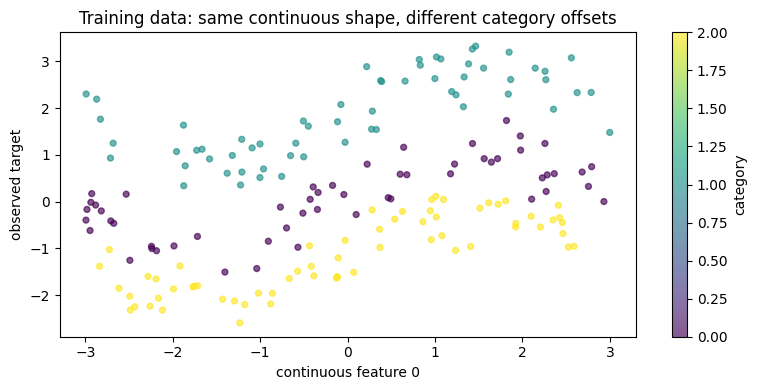

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(3)
offsets = np.array([0.0, 1.8, -1.2], dtype=np.float32)
X_cont = rng.uniform([-3, -2], [3, 2], size=(180, 2)).astype(np.float32)
cats = rng.integers(0, 3, size=180, endpoint=False)
X_train = np.column_stack([X_cont, cats]).astype(np.float32)

def mixed_signal(X_cont_eval, category_eval):
    return (
        np.sin(X_cont_eval[:, 0])
        + 0.3 * X_cont_eval[:, 1]
        + offsets[category_eval.astype(np.int64)]
    ).astype(np.float32)

y_train = (
    mixed_signal(X_cont, cats) + 0.18 * rng.standard_normal(180)
).astype(np.float32)

X_cont_test = rng.uniform([-3, -2], [3, 2], size=(90, 2)).astype(np.float32)
cats_test = rng.integers(0, 3, size=90, endpoint=False)
X_test = np.column_stack([X_cont_test, cats_test]).astype(np.float32)
y_test = mixed_signal(X_cont_test, cats_test)

_fig, _ax = plt.subplots(figsize=(8, 4))
_scatter = _ax.scatter(
    X_train[:, 0],
    y_train,
    c=X_train[:, 2],
    cmap="viridis",
    s=18,
    alpha=0.65,
)
_ax.set_title("Training data: same continuous shape, different category offsets")
_ax.set_xlabel("continuous feature 0")
_ax.set_ylabel("observed target")
_fig.colorbar(_scatter, ax=_ax, label="category")
_fig.tight_layout()
mo.mpl.interactive(_fig)

/home/ajxps/projects/mojogp/mojogp/gp.py:1240: ExperimentalFeatureWarning: MojoGP feature 'SingleOutput: Mixed' on 'SingleOutput: Mixed' is exp. Scope: Mixed continuous-categorical single-output support is public on a narrow tested scope.
  warn_surface_status(surface, stacklevel=2)
/home/ajxps/projects/mojogp/mojogp/feature_support.py:724: ExperimentalFeatureWarning: MojoGP feature 'Active dimensions' on 'SingleOutput: Mixed' is exp.
  check_feature_support(TABLE_MAIN, surface, "active_dims", stacklevel=stacklevel)
/home/ajxps/projects/mojogp/mojogp/feature_support.py:728: ExperimentalFeatureWarning: MojoGP feature 'Product composites' on 'SingleOutput: Mixed' is exp.
  check_feature_support(TABLE_MAIN, surface, "product_composites", stacklevel=stacklevel)
/home/ajxps/projects/mojogp/mojogp/gp.py:1367: ExperimentalFeatureWarning: MojoGP feature 'Materialized Training' on 'SingleOutput: Mixed' is exp.
  check_feature_support(TABLE_EXECUTION, surface, route_feature, stacklevel=2)
/home/

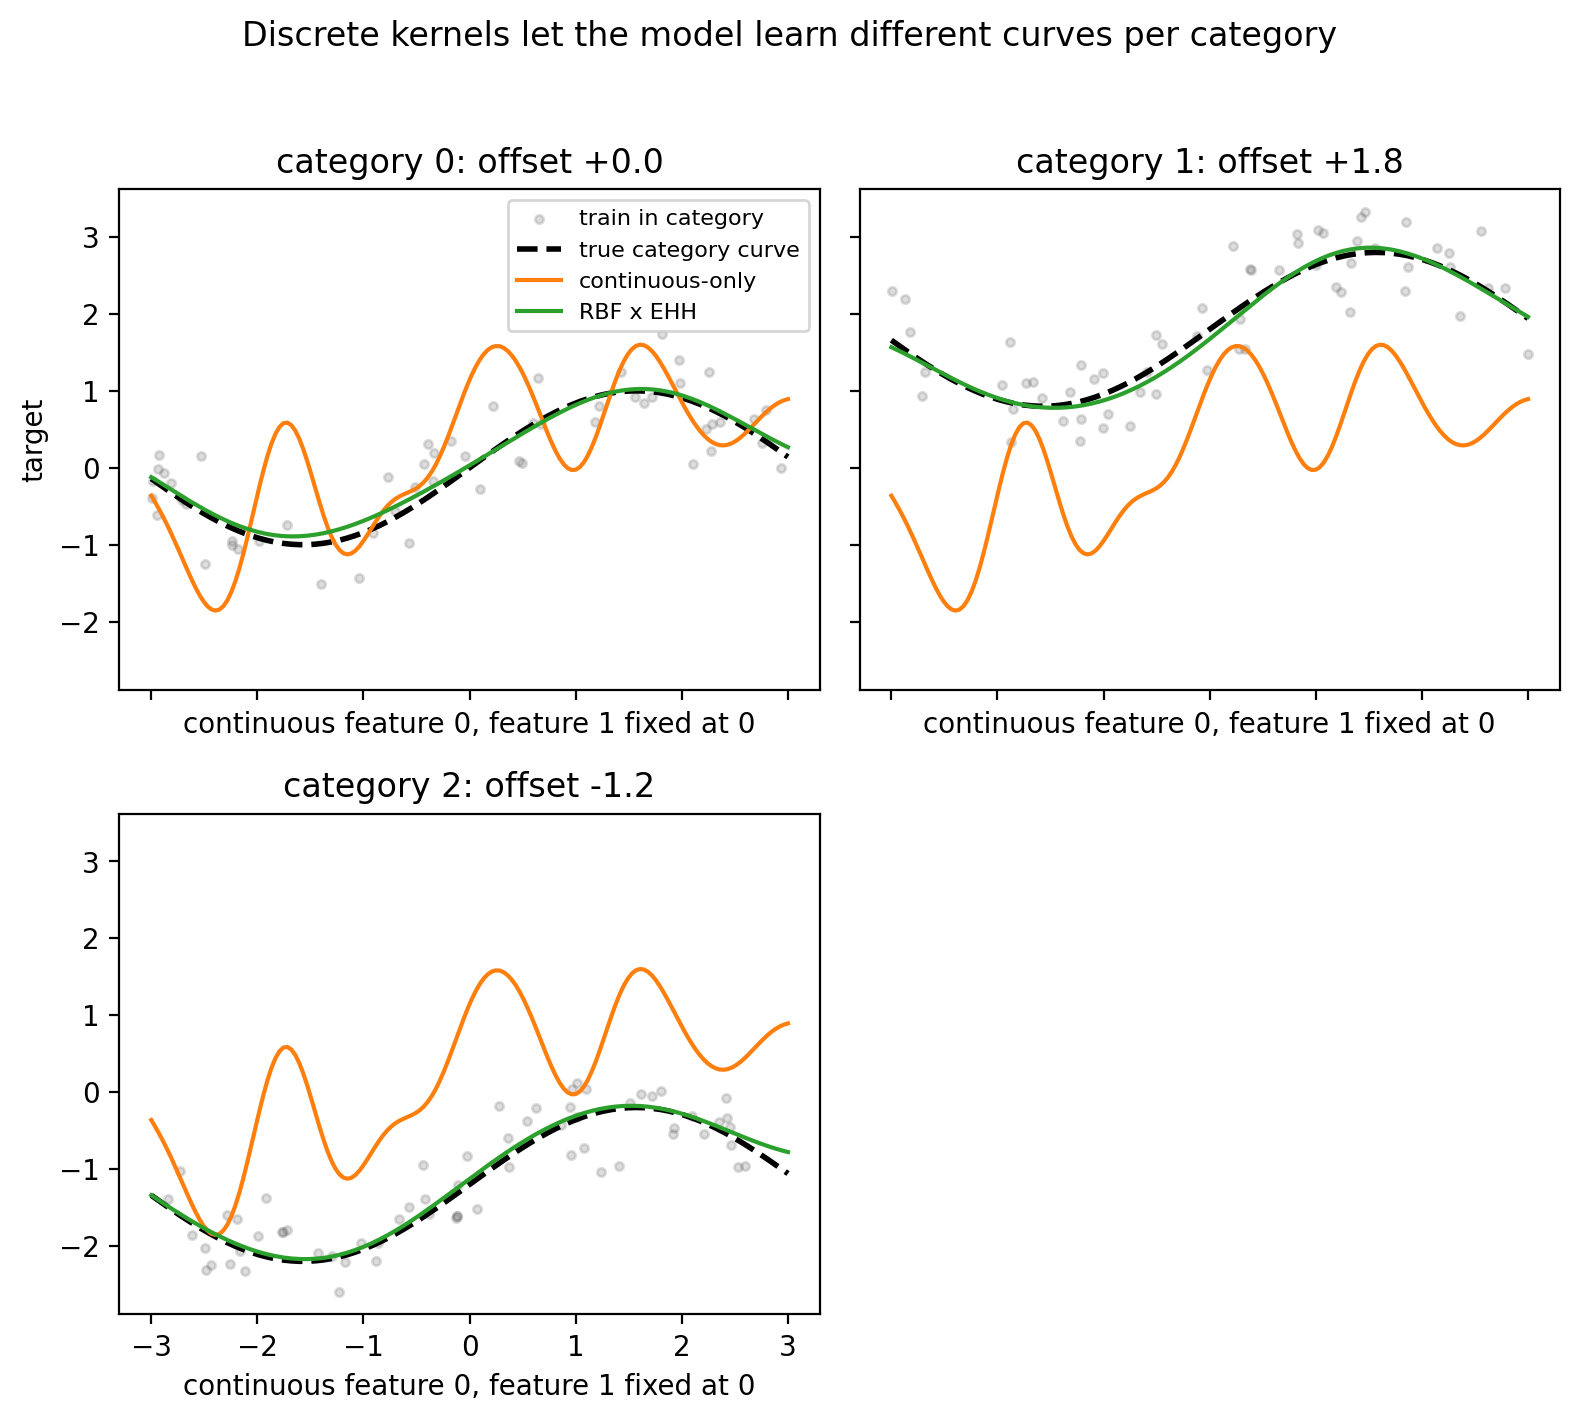

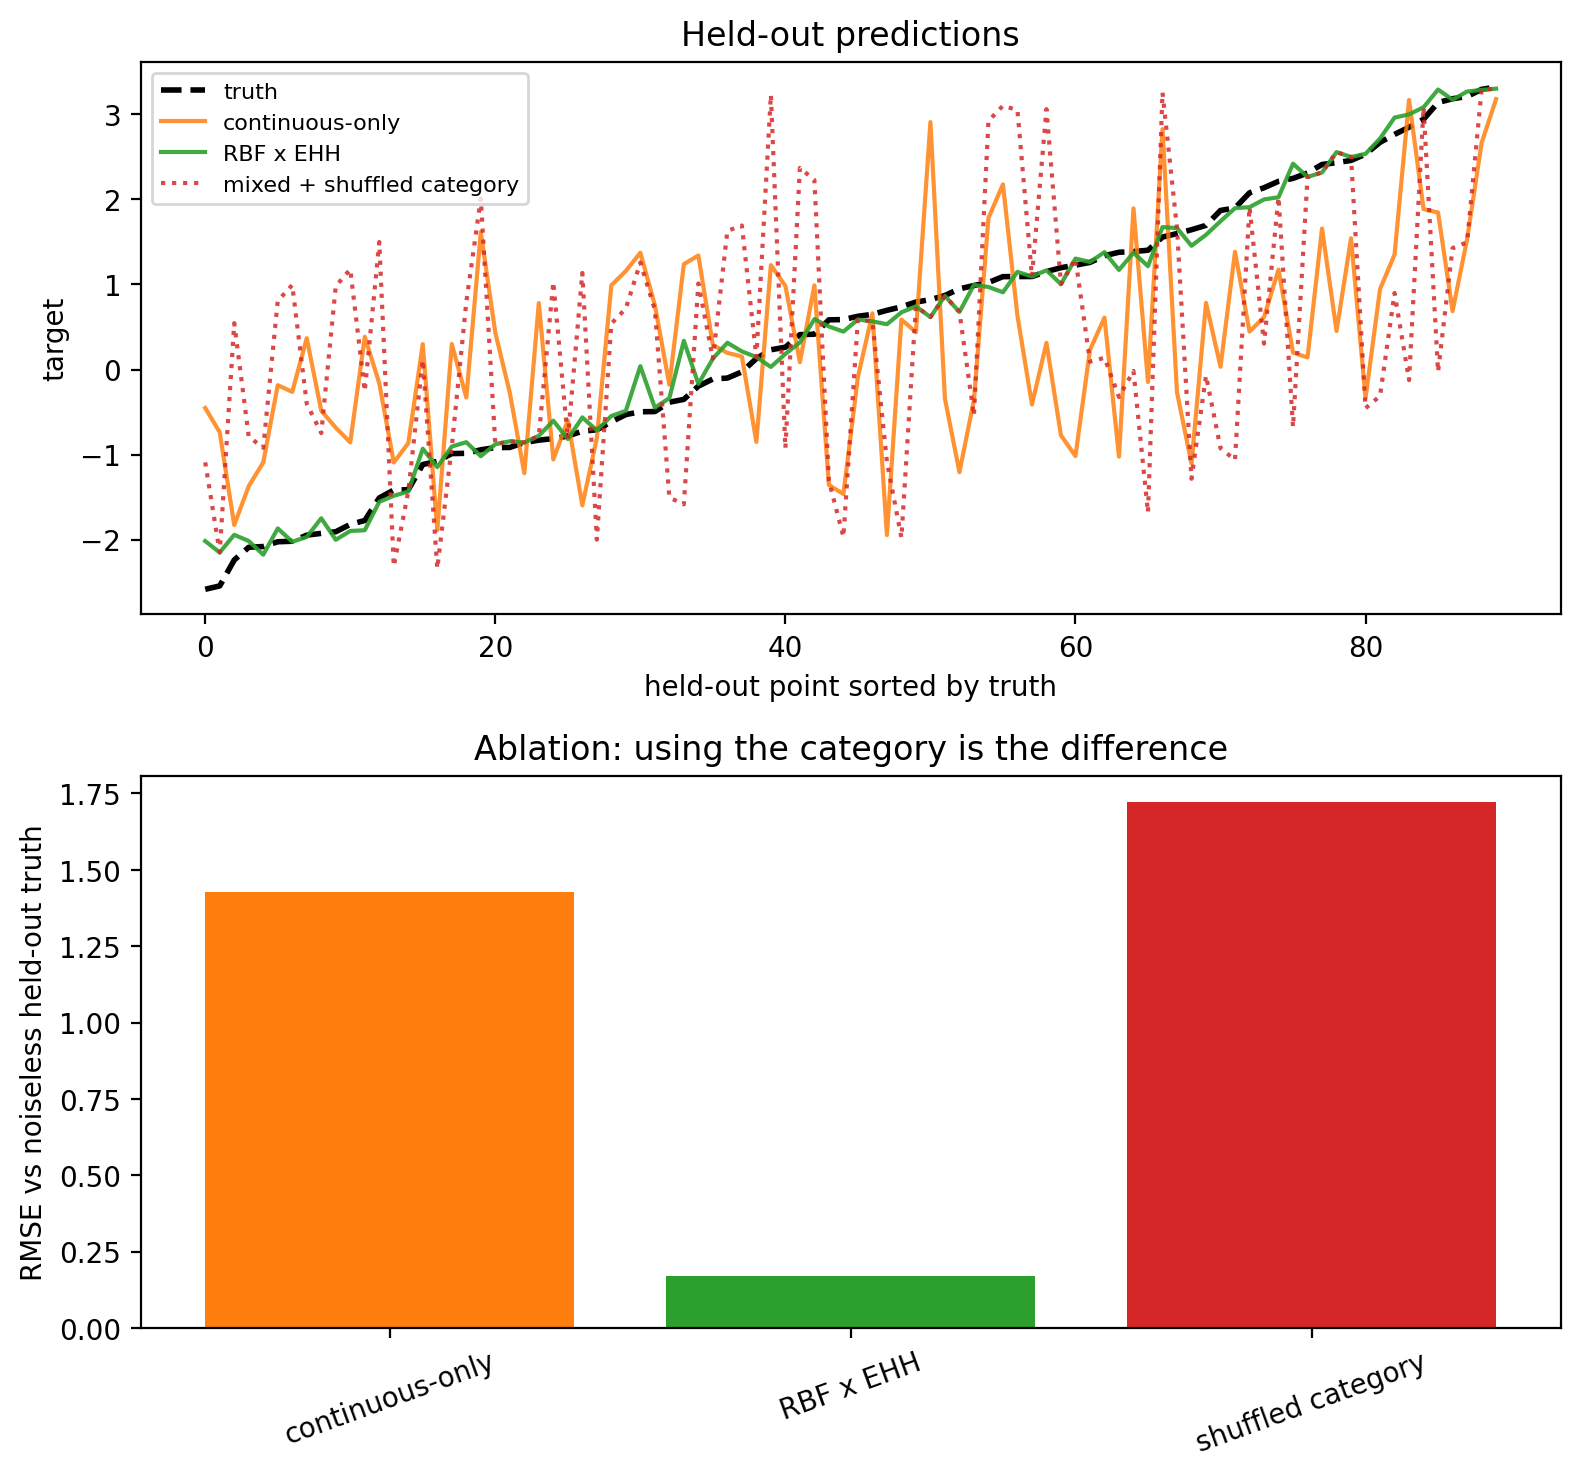

<marimo-table data-initial-value='[]' data-label='"<span class=\"markdown prose dark:prose-invert contents\"><span class=\"paragraph\">Mixed categorical input ablation</span></span>"' data-data='"[{\"Model / control\":\"Continuous-only RBF\",\"What it can know\":\"x0 and x1 only\",\"RMSE\":\"1.4262\"},{\"Model / control\":\"Mixed RBF x EHH\",\"What it can know\":\"x0, x1, and category\",\"RMSE\":\"0.1715\"},{\"Model / control\":\"Mixed with shuffled test categories\",\"What it can know\":\"wrong category labels\",\"RMSE\":\"1.7220\"}]"' data-total-rows='3' data-total-columns='3' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-selection='"multi"' data-show-filters='false' data-show-download='false' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'> The mixed model reaches 0.120x 
the continuous-only RMSE because it can learn that category is a
separate discrete input, not a smooth numeric coordinate. When the
category labels are shuffled at prediction time, the same trained
model loses that mapping and the RMSE gets worse. 
 Discrete Pattern 
 Keep the integer-coded categorical feature in X , then attach a
categorical kernel to that column with active_dims : 
 kernel = RBF ( active_dims = [ 0 , 1 ]) * EHH ( levels = 3 , active_dims = [ 2 ]) 
 gp = SingleOutputGP ( kernel ) 
 
 The same pattern works for GD , CR , HH , and FE .
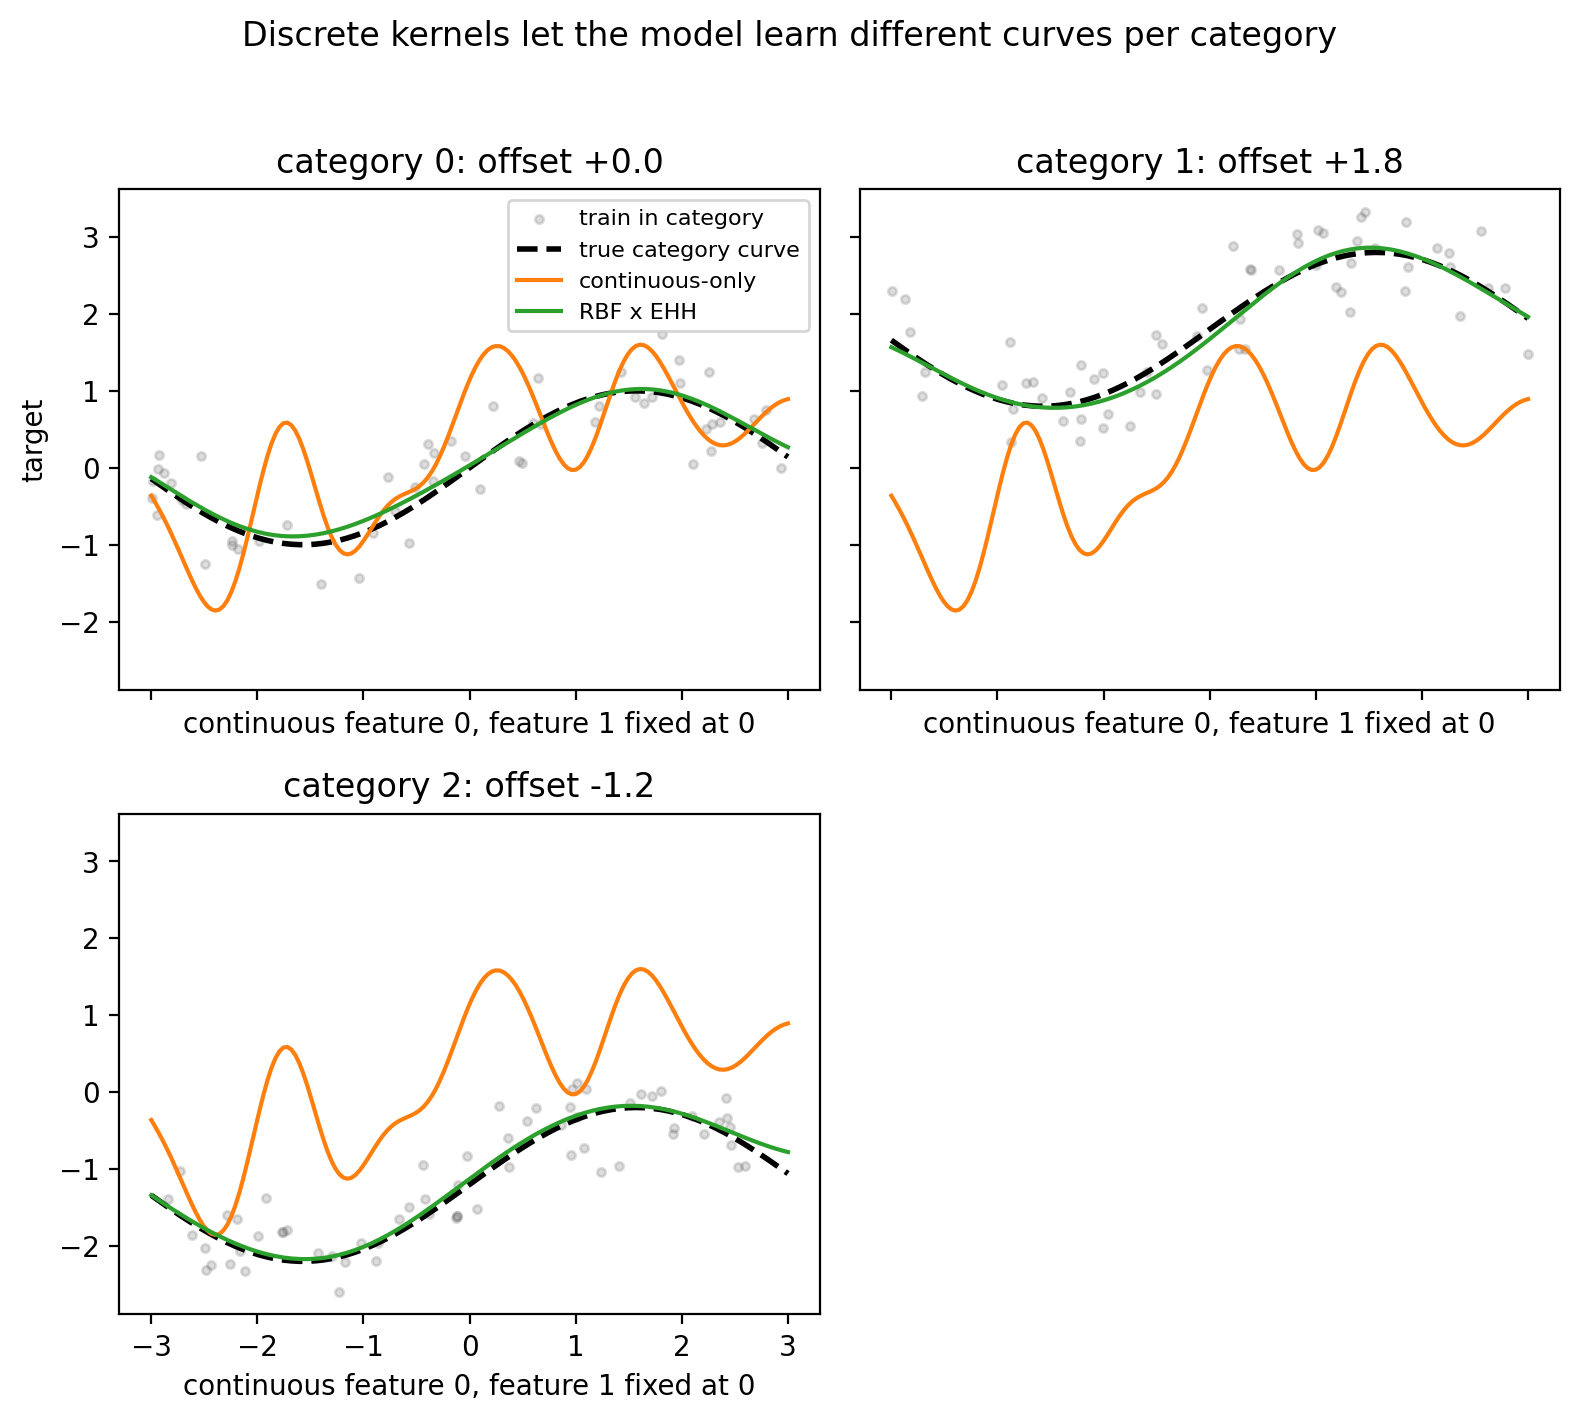
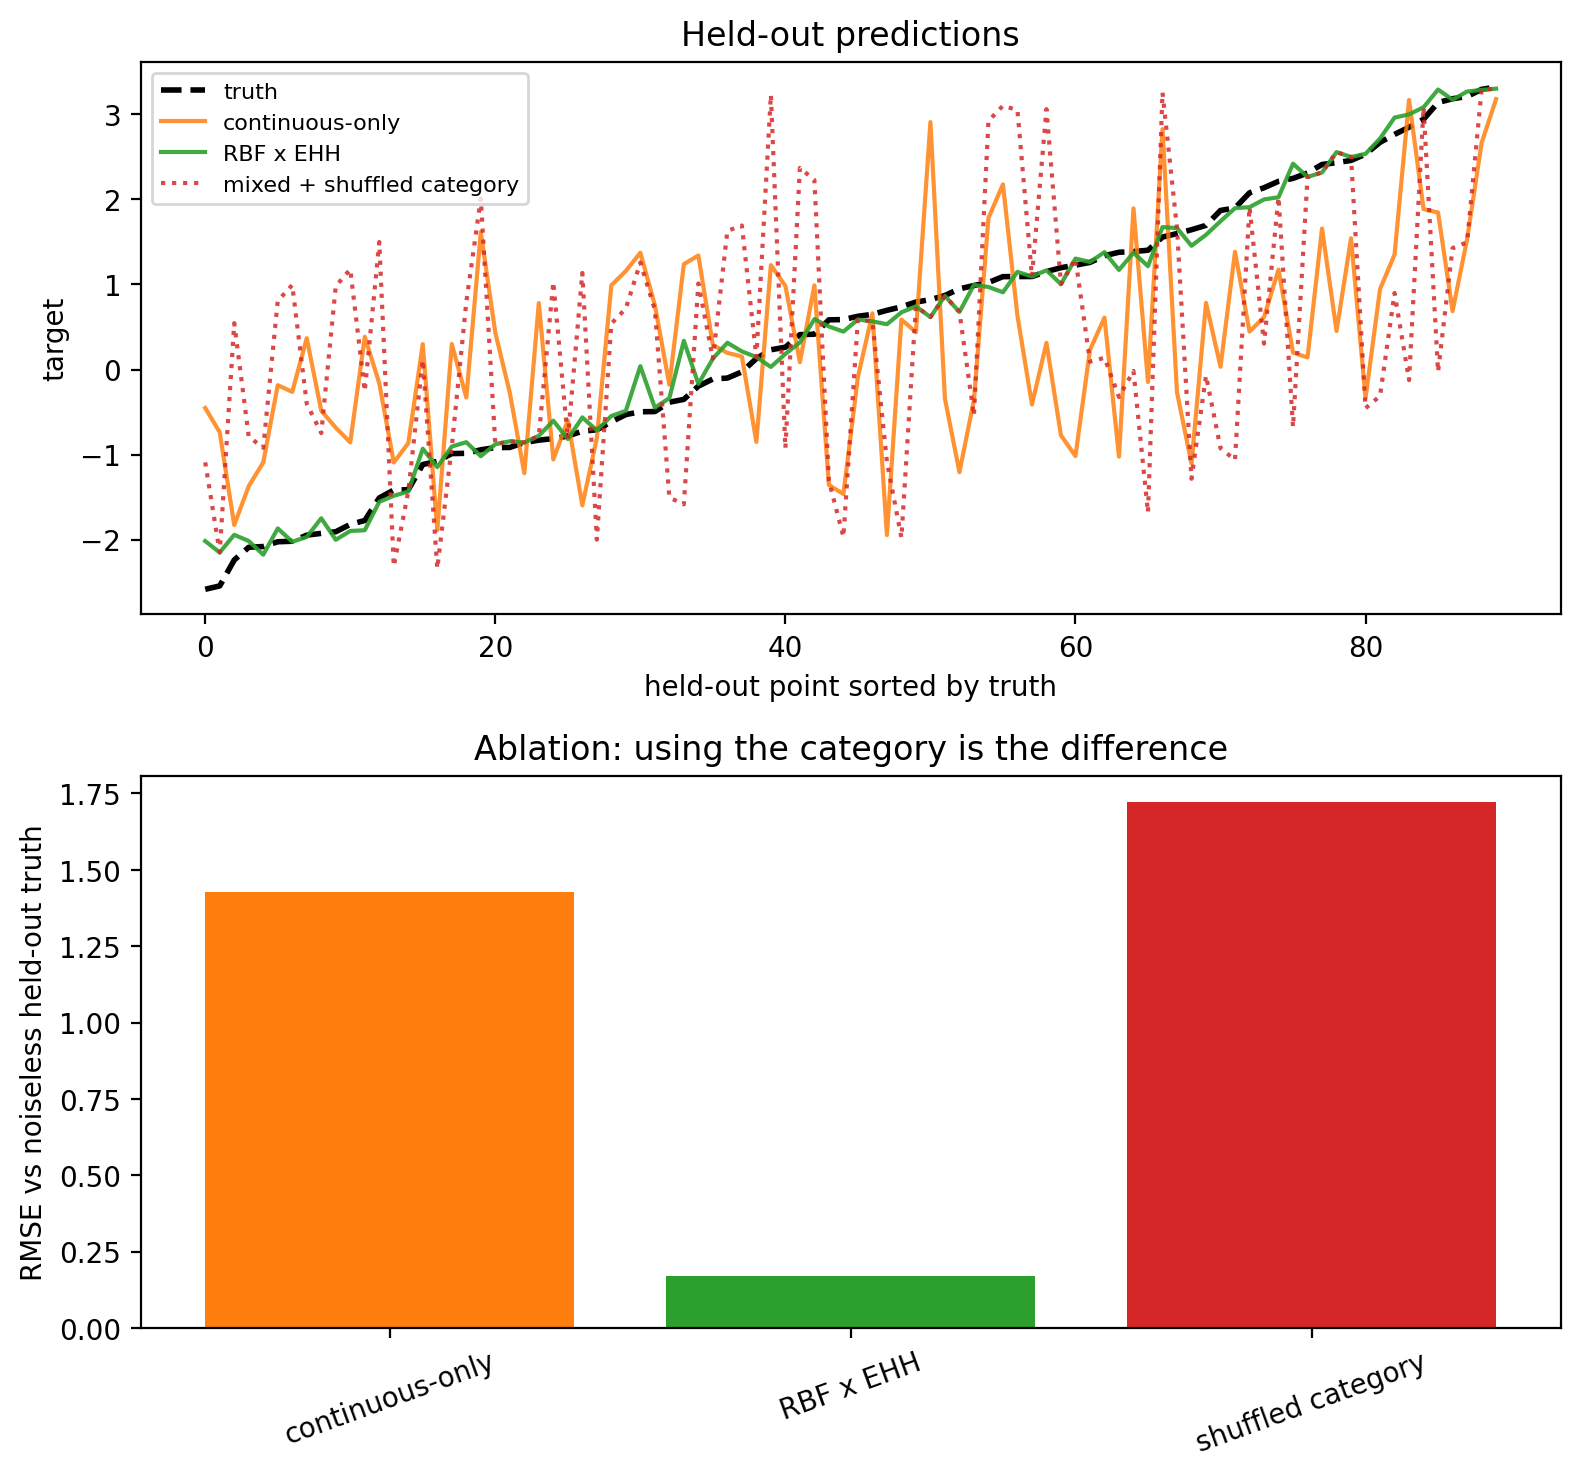

In [ ]:
from mojogp import CR, EHH, FE, GD, HH, RBF, SingleOutputGP

continuous_only = SingleOutputGP(RBF(active_dims=[0, 1]))
continuous_result = continuous_only.fit(
    X_train,
    y_train,
    max_iterations=30,
    learning_rate=0.04,
    method="materialized",
    progress=True,
)
continuous_mean = continuous_only.predict(
    X_test,
    variance_method="mean_only",
    progress=True,
).mean

mixed_kernel = RBF(active_dims=[0, 1]) * EHH(levels=3, active_dims=[2])
mixed = SingleOutputGP(mixed_kernel)
mixed_result = mixed.fit(
    X_train,
    y_train,
    max_iterations=30,
    learning_rate=0.04,
    method="materialized",
    progress=True,
)
mixed_mean = mixed.predict(X_test, variance_method="mean_only", progress=True).mean

_shuffle_rng = np.random.default_rng(303)
X_test_shuffled = X_test.copy()
X_test_shuffled[:, 2] = _shuffle_rng.permutation(X_test_shuffled[:, 2])
shuffled_mean = mixed.predict(
    X_test_shuffled,
    variance_method="mean_only",
    progress=True,
).mean

def rmse(pred):
    return float(np.sqrt(np.mean((pred - y_test) ** 2)))

metrics = {
    "continuous_rmse": rmse(continuous_mean),
    "mixed_rmse": rmse(mixed_mean),
    "shuffled_rmse": rmse(shuffled_mean),
}
metrics["mixed_vs_continuous_ratio"] = metrics["mixed_rmse"] / metrics["continuous_rmse"]
metrics["mixed_vs_shuffled_ratio"] = metrics["mixed_rmse"] / metrics["shuffled_rmse"]

_x_line = np.linspace(-3, 3, 160, dtype=np.float32)
_x2_line = np.zeros_like(_x_line)
_fig_curves, _curve_grid = plt.subplots(2, 2, figsize=(8, 7.2), sharex=True, sharey=True)
_curve_axes = _curve_grid.ravel()
for _cat in range(len(offsets)):
    _ax = _curve_axes[_cat]
    _category_column = np.full_like(_x_line, float(_cat), dtype=np.float32)
    _X_curve = np.column_stack([_x_line, _x2_line, _category_column]).astype(np.float32)
    _curve_truth = mixed_signal(_X_curve[:, :2], _X_curve[:, 2].astype(np.int64))
    _curve_continuous = continuous_only.predict(
        _X_curve,
        variance_method="mean_only",
        progress=True,
    ).mean
    _curve_mixed = mixed.predict(
        _X_curve,
        variance_method="mean_only",
        progress=True,
    ).mean
    _train_mask = X_train[:, 2] == float(_cat)
    _ax.scatter(
        X_train[_train_mask, 0],
        y_train[_train_mask],
        s=9,
        alpha=0.20,
        color="0.35",
        label="train in category" if _cat == 0 else None,
    )
    _ax.plot(_x_line, _curve_truth, "k--", linewidth=2, label="true category curve")
    _ax.plot(_x_line, _curve_continuous, color="tab:orange", label="continuous-only")
    _ax.plot(_x_line, _curve_mixed, color="tab:green", label="RBF x EHH")
    _ax.set_title(f"category {_cat}: offset {offsets[_cat]:+.1f}")
    _ax.set_xlabel("continuous feature 0, feature 1 fixed at 0")
_curve_axes[0].set_ylabel("target")
_curve_axes[0].legend(fontsize=8)
for _ax in _curve_axes[len(offsets) :]:
    _ax.axis("off")
_fig_curves.suptitle("Discrete kernels let the model learn different curves per category")
_fig_curves.tight_layout(rect=(0, 0, 1, 0.96))

_order = np.argsort(y_test)
_fig_eval, _eval_axes = plt.subplots(2, 1, figsize=(8, 7.5))
_eval_axes[0].plot(y_test[_order], "k--", linewidth=2, label="truth")
_eval_axes[0].plot(continuous_mean[_order], color="tab:orange", alpha=0.85, label="continuous-only")
_eval_axes[0].plot(mixed_mean[_order], color="tab:green", alpha=0.9, label="RBF x EHH")
_eval_axes[0].plot(
    shuffled_mean[_order],
    color="tab:red",
    linestyle=":",
    alpha=0.85,
    label="mixed + shuffled category",
)
_eval_axes[0].set_title("Held-out predictions")
_eval_axes[0].set_xlabel("held-out point sorted by truth")
_eval_axes[0].set_ylabel("target")
_eval_axes[0].legend(fontsize=8)

_bar_names = ["continuous-only", "RBF x EHH", "shuffled category"]
_bar_values = [metrics["continuous_rmse"], metrics["mixed_rmse"], metrics["shuffled_rmse"]]
_eval_axes[1].bar(_bar_names, _bar_values, color=["tab:orange", "tab:green", "tab:red"])
_eval_axes[1].set_ylabel("RMSE vs noiseless held-out truth")
_eval_axes[1].set_title("Ablation: using the category is the difference")
_eval_axes[1].tick_params(axis="x", rotation=20)
_fig_eval.tight_layout()

summary_rows = [
    {
        "Model / control": "Continuous-only RBF",
        "What it can know": "x0 and x1 only",
        "RMSE": f"{metrics['continuous_rmse']:.4f}",
    },
    {
        "Model / control": "Mixed RBF x EHH",
        "What it can know": "x0, x1, and category",
        "RMSE": f"{metrics['mixed_rmse']:.4f}",
    },
    {
        "Model / control": "Mixed with shuffled test categories",
        "What it can know": "wrong category labels",
        "RMSE": f"{metrics['shuffled_rmse']:.4f}",
    },
]

mo.vstack(
    [
        mo.mpl.interactive(_fig_curves),
        mo.mpl.interactive(_fig_eval),
        mo.ui.table(summary_rows, label="Mixed categorical input ablation"),
        mo.md(
            f"""
            The mixed model reaches `{metrics['mixed_vs_continuous_ratio']:.3f}x`
            the continuous-only RMSE because it can learn that category is a
            separate discrete input, not a smooth numeric coordinate. When the
            category labels are shuffled at prediction time, the same trained
            model loses that mapping and the RMSE gets worse.

            ## Discrete Pattern

            Keep the integer-coded categorical feature in `X`, then attach a
            categorical kernel to that column with `active_dims`:

            ```python
            kernel = RBF(active_dims=[0, 1]) * EHH(levels=3, active_dims=[2])
            gp = SingleOutputGP(kernel)
            ```

            The same pattern works for `GD`, `CR`, `HH`, and `FE`.
            """
        ),
    ]
)

## References

Saves, P., Diouane, Y., Bartoli, N., Lefebvre, T. and Morlier, J. (2023). A mixed-categorical correlation kernel for Gaussian process. Neurocomputing, [online] 550, p.126472. doi:https://doi.org/10.1016/j.neucom.2023.126472.

Roustant, O., Padonou, E., Deville, Y., Clément, A., Perrin, G., Giorla, J. and Wynn, H. (2018). Group kernels for Gaussian process metamodels with categorical inputs. [online] arXiv.org. Available at: https://arxiv.org/abs/1802.02368 [Accessed 22 May 2026].

Peter, Wu, H. and Wu, C.Y. (2008). Gaussian Process Models for Computer Experiments With Qualitative and Quantitative Factors. 50(3), pp.383–396. doi:https://doi.org/10.1198/004017008000000262.

Zhou, Q., Peter Z.G. Qian and Zhou, S. (2011). A Simple Approach to Emulation for Computer Models With Qualitative and Quantitative Factors. Technometrics, 53(3), pp.266–273. doi:https://doi.org/10.1198/tech.2011.10025.